# 4.6.4 切向增长奇异几何与预测边界

## 学习目标与先修知识

能推导连续变分方程，按实际时间汇总分段增长，区分有限方向增长、长期最大指数与严格存在性。

先修：3.4 的局部线性化（linearization），4.4 的离散增长率与对数，4.6.2 的 RK4 和 4.6.3 的截面。

## 具体问题

两条轨迹（trajectory）的距离最终饱和，怎样持续测量微小扰动的局部增长？把扰动反复缩回一个很小的长度，能否持续记录沿轨迹的伸长率？

In [1]:
import math
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import Markdown, display
from systems_science import plot_style, show_table
plot_style()
BLUE, PINK, GREEN, GRAY = '#008bfb', '#ff0051', '#009e73', '#555555'

## 初步实验

In [2]:
segments=np.array([2.,.5,4.]);durations=np.array([1.,1.,2.])
print("累计对数伸长 / 时间 =",np.log(segments).sum()/durations.sum())

累计对数伸长 / 时间 = 0.34657359027997264


## 模型假设

固定 Lorenz σ=10、β=8/3、ρ=28、初值（initial condition） [1,1,1]、方向 [1,0,0]；先让状态（state）与方向共同演化 10τ，再测量。按 .1τ 归一化，改变步长、方向、预热与观察窗做对照。线性扰动向量（vector）可归一到 1，因为变分方程对扰动线性；与两条真实轨迹比较时才乘小 ε。

## 数学解释与推导

对 x′=f(x)，把邻近状态代入 Taylor 展开：f(x+δ)=f(x)+J(x)δ+O(‖δ‖²)，相减并保留一阶项，得到**连续变分方程**
$$\dot\delta=J(x(t))\delta.$$
状态和扰动必须作为耦合系统同时积分；每个 RK4 阶段使用该阶段的状态计算 J，不能把整步的 J 冻结在段首。每段从范数（norm） ε 出发，记录结束范数 ‖δᵢ⁻‖，再令 δ←εδ/‖δ‖。累计量为
$$\lambda_T=\frac{\sum_i\log(\|\delta_i^-\|/\varepsilon)}{\sum_i\Delta t_i}.$$
分母是实际累计时间，单位为每单位 τ；离散映射按步数归一，两者不能直接混用。初始方向经过预热通常更接近优势方向，但有限方向增长不自动等于最大长期 Lyapunov 指数（Lyapunov exponent）；特殊方向、精确平衡（equilibrium）和短窗都可能改变结果。

用 δ′=diag(1,−2,0)δ 检验：沿第一轴任意窗口得 +1，沿第二轴得 −2。两方向的差别无需混沌（chaos）即可发生。短时间内两条真实轨迹的中心差分（central difference） $[\Phi_t(x+\epsilon v)-\Phi_t(x-\epsilon v)]/(2\epsilon)$ 应接近变分方程的解；过小 ε 会受到舍入，过大 ε 则受高阶项影响。

**奇异吸引子（strange attractor）**强调复杂几何，混沌强调动力学性质，并非在所有系统中同义。准周期（quasiperiodicity）反例：θ′=1、φ′=√2，各自在圆上运动。因为两频率比无理，一般不会同时整圈回归，但两解的相位（phase）差不增长；非周期不等于指数敏感。两个圆的乘积可理解为两个独立钟面的组合；是否吸引邻近状态还要检查横向运动。

本节不从有限点云的盒计数斜率（slope）宣称严格分形维数（fractal dimension）。Lorenz 严格存在性研究使用额外理论和经验证的数值，普通浮点积分与单次正增长均不构成该证明。

## 核心实现

把推导逐步写成函数；不以黑箱轨迹代替方程。

In [3]:
def lorenz_rhs(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([sigma*(y-x),rho*x-y-x*z,x*y-beta*z])

def lorenz_jacobian(state, sigma=10., rho=28., beta=8/3):
    x,y,z=state
    return np.array([[-sigma,sigma,0],[rho-z,-1,-x],[y,x,-beta]])

def rk4_step(rhs, state, h):
    a=rhs(state)
    b=rhs(state+h*a/2)
    c=rhs(state+h*b/2)
    d=rhs(state+h*c)
    return state+h*(a+2*b+2*c+d)/6

def lorenz_path(initial, sigma=10., rho=28., beta=8/3, h=.01, steps=4000):
    state=np.array(initial,dtype=float)
    rows=[state.copy()]
    for _ in range(steps):
        state=rk4_step(lambda v:lorenz_rhs(v,sigma,rho,beta),state,h)
        if not np.all(np.isfinite(state)):
            raise ValueError('数值结果非有限，请减小步长并检查参数。')
        rows.append(state.copy())
    return np.array(rows)

def tangent_path(initial, sigma=10., rho=28., beta=8/3, h=.01, steps=4000,
                 segment_steps=10, burn_steps=1000, direction=(1.,0.,0.)):
    state=np.array(initial,dtype=float)
    delta=np.array(direction,dtype=float)
    if np.linalg.norm(delta)==0:
        raise ValueError('扰动方向必须非零。')
    delta/=np.linalg.norm(delta)
    total_log=0.; total_time=0.; records=[]
    def coupled(v):
        return np.r_[lorenz_rhs(v[:3],sigma,rho,beta),lorenz_jacobian(v[:3],sigma,rho,beta)@v[3:]]
    for start in range(0,steps,segment_steps):
        # Split at burn so only measured elapsed time enters the denominator.
        stop=min(start+segment_steps,steps)
        for i in range(start,stop):
            combined=rk4_step(coupled,np.r_[state,delta],h)
            state,delta=combined[:3],combined[3:]
            if i+1==burn_steps:
                delta/=np.linalg.norm(delta)
        norm=np.linalg.norm(delta)
        if norm==0 or not np.isfinite(norm):raise ValueError('切向范数失效，请检查步长。')
        duration=max(0,stop-max(start,burn_steps))*h
        if duration>0:
            total_log+=math.log(norm);total_time+=duration
            records.append([stop*h,total_log/total_time])
        delta/=norm
    return np.array(records).reshape(-1,2)

## 对照实验

h= 0.01 终点有限方向增长率= 0.880595937369134


h= 0.005 终点有限方向增长率= 0.8514066301615603


C:\Users\10149\AppData\Local\Temp\ipykernel_20940\1362066331.py:12: UserWarning: The figure layout has changed to tight
  fig.tight_layout();plt.show()


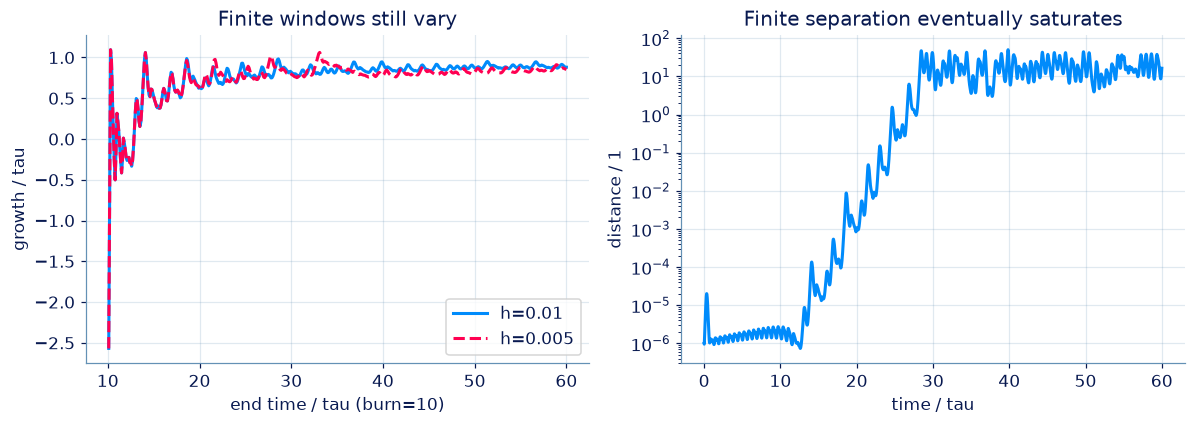

方向/预热/间隔/终点： [0, 1, 0] 10 0.1 60 结果： 0.868626


方向/预热/间隔/终点： [1, 0, 0] 20 0.1 60 结果： 0.9405


方向/预热/间隔/终点： [1, 0, 0] 10 0.2 60 结果： 0.880596
方向/预热/间隔/终点： [1, 0, 0] 10 0.1 40 结果： 0.929256


In [4]:

fig,axes=plt.subplots(1,2,figsize=(11,4))
for h,color,style in [(.01,BLUE,'-'),(.005,PINK,'--')]:
    record=tangent_path([1,1,1],h=h,steps=round(60/h),segment_steps=round(.1/h),burn_steps=round(10/h))
    axes[0].plot(record[:,0],record[:,1],style,color=color,label=f'h={h}')
    print('h=',h,'终点有限方向增长率=',record[-1,1])
axes[0].set(xlabel='end time / tau (burn=10)',ylabel='growth / tau',title='Finite windows still vary');axes[0].legend()
base=lorenz_path([1,1,1],h=.01,steps=6000)
near=lorenz_path([1+1e-6,1,1],h=.01,steps=6000)
distance=np.linalg.norm(base-near,axis=1);times=np.arange(len(base))*.01
axes[1].semilogy(times,np.maximum(distance,1e-16),color=BLUE)
axes[1].set(xlabel='time / tau',ylabel='distance / 1',title='Finite separation eventually saturates')
fig.tight_layout();plt.show()
for direction,burn,interval,end in [([0,1,0],10,.1,60),([1,0,0],20,.1,60),([1,0,0],10,.2,60),([1,0,0],10,.1,40)]:
    rates=tangent_path([1,1,1],h=.01,steps=round(end/.01),segment_steps=round(interval/.01),burn_steps=round(burn/.01),direction=direction)
    print('方向/预热/间隔/终点：',direction,burn,interval,end,'结果：',round(rates[-1,1],6))

## 结果解释

相近初值的距离不能无限指数增长，因为状态被限制在有界范围；分段归一化使局部伸长仍能继续累计。两个步长在长窗的累计量可能接近却不重合，短窗读数也可暂时为负。报告数值时同时给出方向、预热、时长和步长，不只保留一个正数字。

### 独立核对

In [5]:
for axis,exact in [(0,1),(1,-2)]:
    delta=np.eye(3)[axis].copy();h=.01
    for _ in range(100):delta=rk4_step(lambda v:np.array([1.,-2.,0.])*v,delta,h)
    assert abs(math.log(np.linalg.norm(delta))-exact)<1e-7
initial=np.array([1.,1.,1.]);direction=np.array([1.,0.,0.]);h=.001
def coupled(v):return np.r_[lorenz_rhs(v[:3]),lorenz_jacobian(v[:3])@v[3:]]
v=np.r_[initial,direction]
for _ in range(100):v=rk4_step(coupled,v,h)
for epsilon in [1e-3,1e-4,1e-5]:
    plus=lorenz_path(initial+epsilon*direction,h=h,steps=100)[-1]
    minus=lorenz_path(initial-epsilon*direction,h=h,steps=100)[-1]
    assert np.linalg.norm((plus-minus)/(2*epsilon)-v[3:])<2e-7
print('解析特征方向与短窗中心差分一致。')

解析特征方向与短窗中心差分一致。


[观察轨迹、距离与定向截面](http://127.0.0.1:8000/chapters/04-06-连续时间混沌与奇异吸引子/explore/)：分别改变初值与计算精度，再对照本节推导。

## 练习与参考资料

先独立作答，再提交核对。

### 第 1 题 · Python 计算题：按实际时间汇总切向增长

已知连续变分方程每段的伸长倍数和时长，汇总给定方向的有限时间增长率。

**函数与代码模板**

```python
def solve(
    stretch_factors: list[float],
    durations: list[float],
) -> float:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `stretch_factors` | `list[float]` | 每段终点范数（norm）除以该段起点范数，均正。 | 1 |
| `durations` | `list[float]` | 与每段对应的实际时长。 | τ |

**返回值**

直接返回 growth_rate（float）。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `growth_rate` | `float` | 窗口内平均对数增长率。 | 每单位 τ |

**计算规则**

每段开始把扰动归一到相同正范数；返回 sum(log(stretch_factors))/sum(durations)。必须用自然对数（natural logarithm）与实际时长，不除以段数。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 1—100 段，两列表等长；各伸长倍数在 [1e−8,1e8]；各时长在 (0,10]。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| stretch_factors | 每段终点范数（norm）除以该段起点范数，均正。 | [2, 0.5, 4] | 1 |
| durations | 与每段对应的实际时长。 | [1, 1, 2] | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
stretch_factors = [2, 0.5, 4]
durations = [1, 1, 2]

result = solve(stretch_factors, durations)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| growth_rate | 窗口内平均对数增长率。 | ≈ 0.3465736 | 每单位 τ |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = 0.34657359027997264
```

**样例解释**

净伸长倍数为 2×0.5×4=4，总时长为 4，结果 ln(4)/4≈0.3465735903。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：按实际时间汇总切向增长](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-tangent-growth)

### 第 2 题 · Python 计算题：用解析线性系统检查切向解

对 δ′=diag(rates)δ，给定三个连续增长率、初始扰动向量（vector）和时刻，返回解析扰动及相对初始范数（norm）的放大倍数。

**函数与代码模板**

```python
def solve(
    rates: list[float],
    initial_delta: list[float],
    time: float,
) -> tuple[list[float], float]:
    raise NotImplementedError("请完成计算")
```

**参数说明**

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `rates` | `list[float]` | 三个对角增长率。 | 每单位 τ |
| `initial_delta` | `list[float]` | 非零的三维初始扰动。 | 1 |
| `time` | `float` | 观察时刻。 | τ |

**返回值**

按以下顺序返回元组：(delta, factor)。

| 名称 | Python 类型 | 含义 | 单位 |
|---|---|---|---|
| `delta` | `list[float]` | 三个扰动分量。 | 1 |
| `factor` | `float` | 终点范数与起点范数之比。 | 1 |

**计算规则**

δⱼ(t)=δⱼ(0)exp(rates[j]*time)，放大倍数用三维欧氏范数。

**约束与边界**

- 所有数值有限，不修改输入（input）列表。
- 两个列表长度 3；rates 在 [−3,3]，initial_delta 非零且有限；0≤time≤4。

**输入样例**

每个参数对应函数签名中的同名变量；单位与顺序见下表。

给定条件

| 参数 | 含义 | 给定值 | 单位 |
| --- | --- | --- | --- |
| rates | 三个对角增长率。 | [1, -2, 0] | 每单位 τ |
| initial_delta | 非零的三维初始扰动。 | [1, 0, 0] | 1 |
| time | 观察时刻。 | 1 | τ |

**输入与调用代码**

完成 solve 函数后，将下面的参数赋值与调用代码放在函数定义下方运行。

```python
rates = [1, -2, 0]
initial_delta = [1, 0, 0]
time = 1

result = solve(rates, initial_delta, time)
print(result)
```

**输出样例**

对这组输入，你的函数应返回下列结果。列表按表格自上而下的顺序排列；标有“≈”的是便于阅读的近似值，请按模型计算完整数值。

计算结果

| 返回项 | 含义 | 结果 | 单位 |
| --- | --- | --- | --- |
| delta | 三个扰动分量。 | [2.718281828459045, 0.0, 0.0] | 1 |
| factor | 终点范数与起点范数之比。 | ≈ 2.718282 | 1 |

**预期输出代码**

用 expected_output 对照 result 的类型、顺序与数值。代码保留样例原始精度，浮点结果按题面容差比较。

```python
expected_output = ([2.718281828459045, 0.0, 0.0],
                   2.718281828459045)
```

**样例解释**

初始方向沿第一轴，t=1 时扰动为 [e,0,0]，放大倍数 e；沿第二轴则衰减。

允许 Python 标准库；绝对误差 1e-08 或相对误差 1e-08。

[作答：用解析线性系统检查切向解](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-linear-tangent)

### 第 3 题 · 单项选择题：增加归一化次数会提高增长率吗

相同总时间的切向演化，仅把归一化间隔减半。哪项正确？

- **A.** 应按总时间归一，分段更密本身不应使增长率翻倍。
- **B.** 应按段数归一，越多段越准确地表示每单位时间。
- **C.** 任何初始方向都会给出最大渐近指数。
- **D.** 零扰动也可先取对数再归一。

[作答：增加归一化次数会提高增长率吗](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-growth-units)

### 第 4 题 · 多项选择题：非周期是否足够说明混沌

两相位（phase） θ′=1、φ′=√2，各自按 2π 取模。哪些说法成立？

- **A.** 一般没有共同有限周期。
- **B.** 两解的相位差保持，非周期并不自动意味着指数敏感。
- **C.** 只看这两条角度方程就知道该环面吸引周围状态（state）。
- **D.** 准周期（quasiperiodicity）和混沌（chaos）在所有系统里同义。

[作答：非周期是否足够说明混沌](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-quasiperiodic-counterexample)

### 第 5 题 · 单项选择题：图像与存在性证明的距离

普通浮点积分得到蝴蝶状轨迹（trajectory），若干长窗口方向增长率为正。最准确的结论是什么？

- **A.** 提供与混沌（chaos）行为相符的数值证据；奇异吸引子（strange attractor）严格存在仍需额外理论与经验证的数值。
- **B.** 本次图像已重现 Tucker 的计算机辅助证明。
- **C.** 正增长证明所有初值（initial condition）都是混沌轨道。
- **D.** 负散度（divergence）单独证明分形维数（fractal dimension）。

[作答：图像与存在性证明的距离](http://127.0.0.1:8000/chapters/04-06-%E8%BF%9E%E7%BB%AD%E6%97%B6%E9%97%B4%E6%B7%B7%E6%B2%8C%E4%B8%8E%E5%A5%87%E5%BC%82%E5%90%B8%E5%BC%95%E5%AD%90/practice/?question=p04-strange-evidence)

### 参考阅读

[MIT 非线性动力学讲义](https://ocw.mit.edu/courses/12-006j-nonlinear-dynamics-chaos-fall-2022/pages/lecture-notes/)：第 15—16 讲的截面，第 19 讲的奇异几何，第 20—21 讲的 Lorenz 方程，第 24 讲的增长率。核心推导与实验均已写在本节。

[Tucker 1999：The Lorenz attractor exists](https://research.monash.edu/en/publications/lattracteur-de-lorenz-existe/) 的存在性结论依赖计算机辅助证明，本实验不复现该证明。